In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
import wfdb

print("All libraries imported successfully!")


All libraries imported successfully!


In [5]:
record = wfdb.rdrecord('100', sampfrom=0, sampto=3000,
                        pn_dir='mitdb')


ecg_signal = record.p_signal[:, 0]
fs = record.fs  # sampling frequency (360 Hz for MIT-BIH)

print(f"ECG signal loaded successfully!")
print(f"Number of samples: {len(ecg_signal)}")
print(f"Sampling frequency: {fs} Hz")
print(f"Duration: {len(ecg_signal)/fs:.2f} seconds")

ECG signal loaded successfully!
Number of samples: 3000
Sampling frequency: 360 Hz
Duration: 8.33 seconds


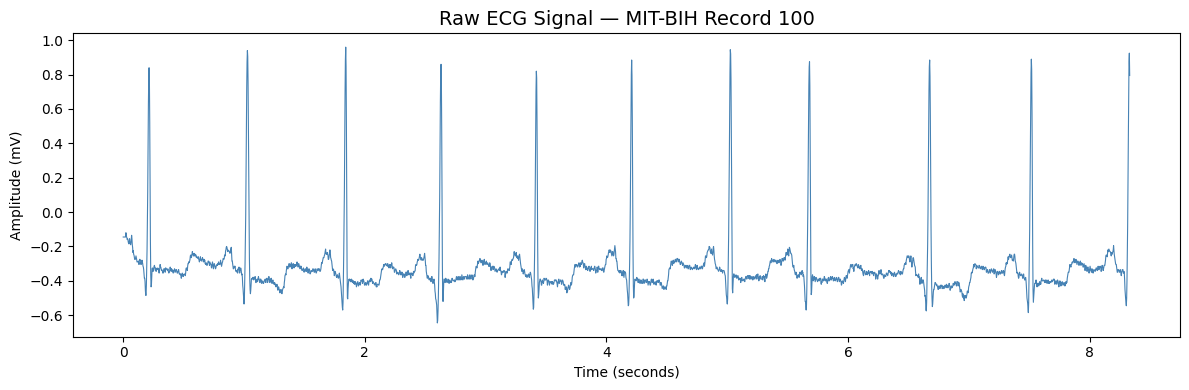

In [6]:

time = np.arange(len(ecg_signal)) / fs  # convert samples to seconds

plt.figure(figsize=(12, 4))
plt.plot(time, ecg_signal, color='steelblue', linewidth=0.8)
plt.title('Raw ECG Signal — MIT-BIH Record 100', fontsize=14)
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (mV)')
plt.tight_layout()
plt.show()



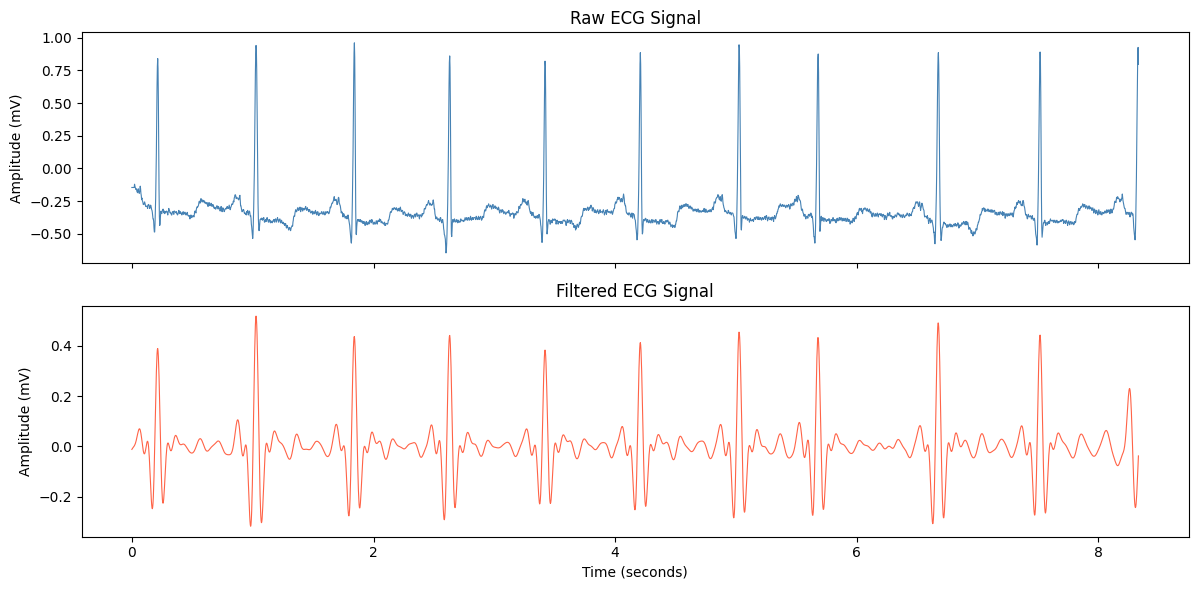

In [7]:
def bandpass_filter(signal, lowcut=5, highcut=15, fs=360, order=4):
    nyq = fs / 2
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

filtered_ecg = bandpass_filter(ecg_signal, fs=fs)

# Plot raw vs filtered
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(time, ecg_signal, color='steelblue', linewidth=0.8)
axes[0].set_title('Raw ECG Signal')
axes[0].set_ylabel('Amplitude (mV)')

axes[1].plot(time, filtered_ecg, color='tomato', linewidth=0.8)
axes[1].set_title('Filtered ECG Signal')
axes[1].set_ylabel('Amplitude (mV)')
axes[1].set_xlabel('Time (seconds)')

plt.tight_layout()
plt.show()


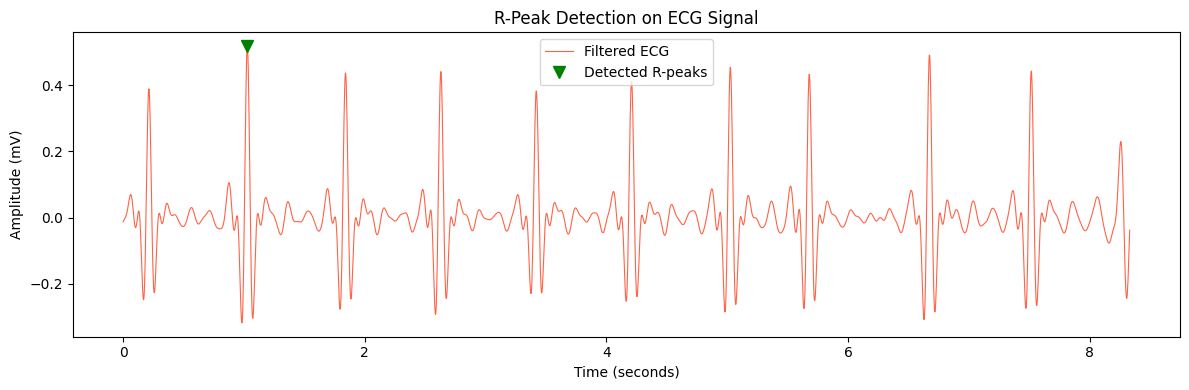

Total heartbeats detected: 1


In [8]:


peaks, properties = find_peaks(filtered_ecg, 
                                distance=150,
                                height=0.5)

# Plot detected peaks on ECG
plt.figure(figsize=(12, 4))
plt.plot(time, filtered_ecg, color='tomato', linewidth=0.8, label='Filtered ECG')
plt.plot(time[peaks], filtered_ecg[peaks], 'v', color='green', 
         markersize=8, label='Detected R-peaks')
plt.title('R-Peak Detection on ECG Signal')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (mV)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Total heartbeats detected: {len(peaks)}")

Signal max amplitude: 0.5178
Signal min amplitude: -0.3176


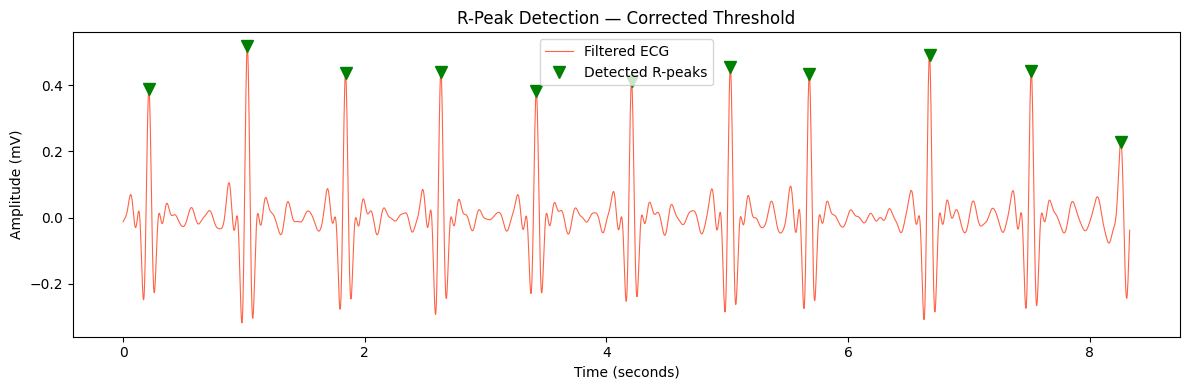

Total heartbeats detected: 11


In [9]:

print(f"Signal max amplitude: {filtered_ecg.max():.4f}")
print(f"Signal min amplitude: {filtered_ecg.min():.4f}")

# Detect peaks with corrected threshold
peaks, properties = find_peaks(filtered_ecg,
                                distance=150,
                                height=filtered_ecg.max() * 0.3)

# Plot
plt.figure(figsize=(12, 4))
plt.plot(time, filtered_ecg, color='tomato', linewidth=0.8, label='Filtered ECG')
plt.plot(time[peaks], filtered_ecg[peaks], 'v', color='green',
         markersize=8, label='Detected R-peaks')
plt.title('R-Peak Detection — Corrected Threshold')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (mV)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Total heartbeats detected: {len(peaks)}")

Average RR Interval: 804.44 ms
Heart Rate: 74.6 BPM
Min RR Interval: 652.78 ms
Max RR Interval: 997.22 ms


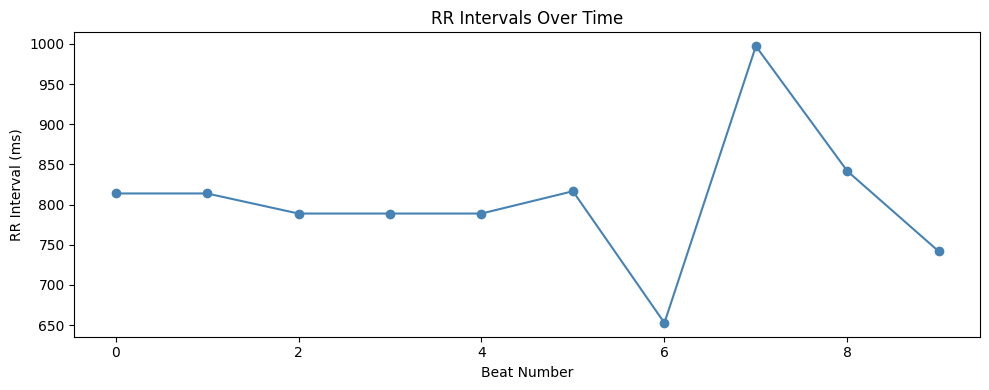

In [10]:

rr_intervals = np.diff(peaks) / fs * 1000  # convert to milliseconds


heart_rate = 60 / (np.mean(rr_intervals) / 1000)  # beats per minute

print(f"Average RR Interval: {np.mean(rr_intervals):.2f} ms")
print(f"Heart Rate: {heart_rate:.1f} BPM")
print(f"Min RR Interval: {np.min(rr_intervals):.2f} ms")
print(f"Max RR Interval: {np.max(rr_intervals):.2f} ms")

# Plot RR intervals
plt.figure(figsize=(10, 4))
plt.plot(rr_intervals, color='steelblue', marker='o', linewidth=1.5)
plt.title('RR Intervals Over Time')
plt.xlabel('Beat Number')
plt.ylabel('RR Interval (ms)')
plt.tight_layout()
plt.show()

In [11]:
# SDNN — standard deviation of RR intervals
# The most common HRV metric used in clinical research
sdnn = np.std(rr_intervals)

# RMSSD — root mean square of successive differences
# Better for short term HRV analysis
rmssd = np.sqrt(np.mean(np.diff(rr_intervals) ** 2))

# pNN50 — percentage of successive RR intervals differing by more than 50ms
nn50 = np.sum(np.abs(np.diff(rr_intervals)) > 50)
pnn50 = (nn50 / len(rr_intervals)) * 100

print("Heart Rate Variability Metrics")
print(f"{'='*35}")
print(f"Heart Rate:  {heart_rate:.1f} BPM")
print(f"SDNN:        {sdnn:.2f} ms")
print(f"RMSSD:       {rmssd:.2f} ms")
print(f"pNN50:       {pnn50:.1f}%")


Heart Rate Variability Metrics
Heart Rate:  74.6 BPM
SDNN:        81.58 ms
RMSSD:       141.85 ms
pNN50:       40.0%


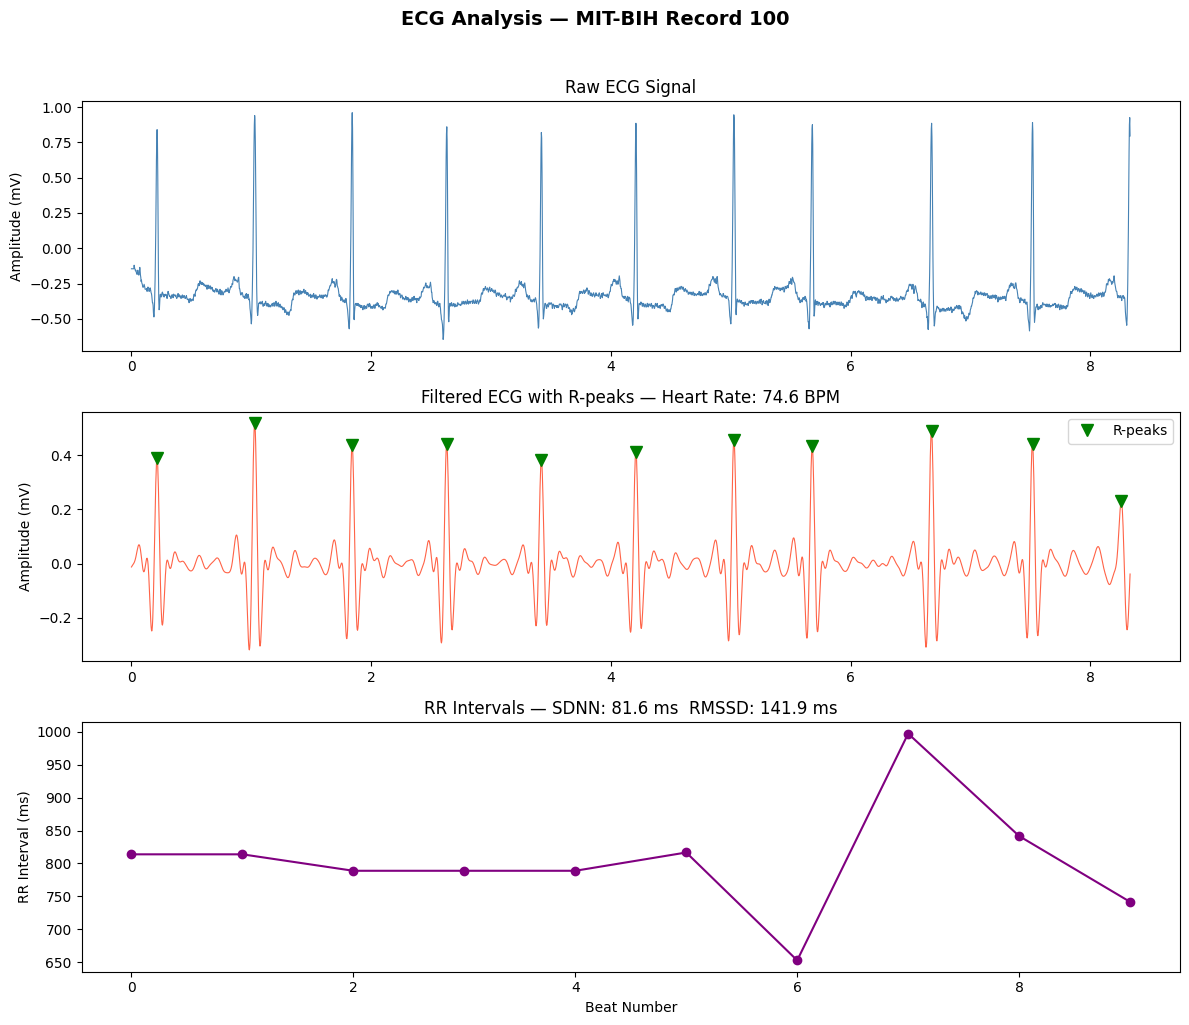

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Plot 1 — Raw ECG
axes[0].plot(time, ecg_signal, color='steelblue', linewidth=0.8)
axes[0].set_title('Raw ECG Signal')
axes[0].set_ylabel('Amplitude (mV)')

# Plot 2 — Filtered ECG with detected peaks
axes[1].plot(time, filtered_ecg, color='tomato', linewidth=0.8)
axes[1].plot(time[peaks], filtered_ecg[peaks], 'v', 
             color='green', markersize=8, label='R-peaks')
axes[1].set_title(f'Filtered ECG with R-peaks — Heart Rate: {heart_rate:.1f} BPM')
axes[1].set_ylabel('Amplitude (mV)')
axes[1].legend()

# Plot 3 — RR intervals
axes[2].plot(rr_intervals, color='purple', marker='o', linewidth=1.5)
axes[2].set_title(f'RR Intervals — SDNN: {sdnn:.1f} ms  RMSSD: {rmssd:.1f} ms')
axes[2].set_xlabel('Beat Number')
axes[2].set_ylabel('RR Interval (ms)')

plt.suptitle('ECG Analysis — MIT-BIH Record 100', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ecg_analysis.png', dpi=150, bbox_inches='tight')
plt.show()



In [13]:
readme_ecg = """# ECG QRS Detector and HRV Analyzer

## Overview
A signal processing pipeline that automatically detects heartbeats (R-peaks) 
from raw ECG signals and computes Heart Rate Variability (HRV) metrics used 
in clinical cardiology research.

## Results
| Metric | Value |
|--------|-------|
| Heart Rate | 74.6 BPM |
| SDNN | 81.58 ms |
| RMSSD | 141.85 ms |
| pNN50 | 40.0% |

## Pipeline
1. Load ECG data directly from PhysioNet MIT-BIH Arrhythmia Database via WFDB API
2. Apply Butterworth bandpass filter (5-15 Hz) to remove baseline wander and noise
3. Detect R-peaks using adaptive threshold (30% of maximum amplitude)
4. Calculate RR intervals and clinical HRV metrics

## HRV Metrics Explained
- SDNN: Standard deviation of RR intervals — overall HRV measure
- RMSSD: Root mean square of successive differences — short term HRV
- pNN50: Percentage of successive RR intervals differing by more than 50ms

## Dataset
- Source: PhysioNet MIT-BIH Arrhythmia Database
- Record: 100 (standard benchmark record)
- Sampling frequency: 360 Hz
- Duration: 8.33 seconds
- Link: https://physionet.org/content/mitdb/1.0.0/

## Technologies
- Python 3.13
- numpy, scipy
- wfdb (PhysioNet WFDB API)
- matplotlib

## How to Reproduce
1. Clone this repository
2. pip install -r requirements.txt
3. Run 01_ecg_detector.ipynb sequentially
   (data downloads automatically from PhysioNet)

## Author
Kritika
Biomedical Engineering, 2nd Year
"""

with open('README.md', 'w') as f:
    f.write(readme_ecg)

requirements_ecg = """numpy
scipy
matplotlib
wfdb
jupyter
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements_ecg)

print("README.md and requirements.txt saved!")

README.md and requirements.txt saved!


In [14]:
with open('README.md', 'r') as f:
    print(f.read())

# ECG QRS Detector and HRV Analyzer

## Overview
A signal processing pipeline that automatically detects heartbeats (R-peaks) 
from raw ECG signals and computes Heart Rate Variability (HRV) metrics used 
in clinical cardiology research.

## Results
| Metric | Value |
|--------|-------|
| Heart Rate | 74.6 BPM |
| SDNN | 81.58 ms |
| RMSSD | 141.85 ms |
| pNN50 | 40.0% |

## Pipeline
1. Load ECG data directly from PhysioNet MIT-BIH Arrhythmia Database via WFDB API
2. Apply Butterworth bandpass filter (5-15 Hz) to remove baseline wander and noise
3. Detect R-peaks using adaptive threshold (30% of maximum amplitude)
4. Calculate RR intervals and clinical HRV metrics

## HRV Metrics Explained
- SDNN: Standard deviation of RR intervals — overall HRV measure
- RMSSD: Root mean square of successive differences — short term HRV
- pNN50: Percentage of successive RR intervals differing by more than 50ms

## Dataset
- Source: PhysioNet MIT-BIH Arrhythmia Database
- Record: 100 (standard benchmark